In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
column_names=['Planet_Name','Status','Score','Period','Radıus','Temp','Star_temp']
df=pd.read_csv(r'temiz_gezegenler.csv',sep=';',names=column_names,header=0)

In [3]:
df.head(2)

,Planet_Name,Status,Score,Period,Radıus,Temp,Star_temp
0,Kepler-227 c,CONFIRMED,9690,54418382848,283.0,4430.0,545500.0
1,Kepler-664 b,CONFIRMED,10000,2525591808,275.0,14060.0,603100.0


In [4]:
df['Radıus']= df['Radıus'] /100
df['Temp']= df['Temp'] /10
df['Score']=df['Score']/1000

In [6]:
print(df[['Radıus','Temp','Score',]].describe().loc[['mean','min','max']])

           Radıus         Temp     Score
mean     4.473644    885.52716   9.40163
min      0.220000    144.00000   0.01000
max   1543.740000  13184.00000  10.00000


In [7]:
onaylı_df=df[df['Status']=='CONFIRMED'].copy()

In [8]:
print(len(onaylı_df))

2258


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
plt.figure(figsize=(12,8))
sns.set_style("whitegrid")

<Figure size 1200x800 with 0 Axes>

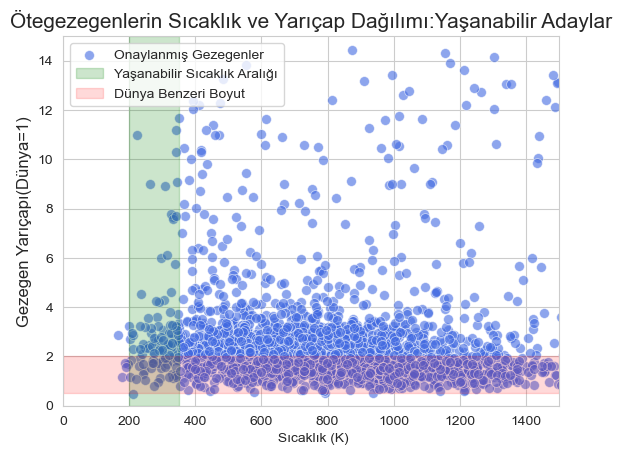

In [27]:
sns.scatterplot(data=onaylı_df,x='Temp',y='Radıus',color='royalblue',alpha=0.6,s=50,label='Onaylanmış Gezegenler')
plt.xlim(0,1500)
plt.ylim(0,15)
plt.axvspan(200,350,color='green',alpha=0.2,label='Yaşanabilir Sıcaklık Aralığı')
plt.axhspan(0.5,2.0,color='red',alpha=0.15,label='Dünya Benzeri Boyut')
plt.title('Ötegezegenlerin Sıcaklık ve Yarıçap Dağılımı:Yaşanabilir Adaylar',fontsize=15)
plt.xlabel(' Sıcaklık (K)')
plt.ylabel('Gezegen Yarıçapı(Dünya=1)',fontsize=12)
plt.legend()
plt.show()

In [28]:
onaylı_df['Score']=onaylı_df['Score']/10

In [31]:
kesin_adaylar= onaylı_df[(onaylı_df['Temp'].between(200,400))&
(onaylı_df['Radıus'].between(0.5,2.0))].sort_values(by='Score',ascending=False)

In [32]:
print(len(kesin_adaylar))

60


In [34]:
kesin_adaylar[['Planet_Name','Temp','Radıus','Score']].head(10)

,Planet_Name,Temp,Radıus,Score
39,Kepler-52 d,332.0,1.99,1.0
49,Kepler-231 c,393.0,1.93,1.0
62,Kepler-235 d,361.0,1.96,1.0
63,Kepler-235 e,273.0,1.83,1.0
85,Kepler-236 c,329.0,1.80,1.0
169,Kepler-54 c,395.0,1.29,1.0
199,Kepler-55 c,349.0,1.85,1.0
971,Kepler-333 c,386.0,1.16,1.0
623,Kepler-296 d,297.0,1.52,1.0
677,Kepler-1651 b,393.0,1.60,1.0


In [35]:
en_iyi_10_aday=kesin_adaylar[['Planet_Name','Temp','Radıus','Score']].head(10)

In [36]:
print("\n İNSANLIĞIN YENİ EVİ OLABİLECEK EN İYİ 10 ADAY")
print("-"*50)
print(en_iyi_10_aday)


 İNSANLIĞIN YENİ EVİ OLABİLECEK EN İYİ 10 ADAY
--------------------------------------------------
       Planet_Name   Temp  Radıus  Score
39     Kepler-52 d  332.0    1.99    1.0
49    Kepler-231 c  393.0    1.93    1.0
62    Kepler-235 d  361.0    1.96    1.0
63    Kepler-235 e  273.0    1.83    1.0
85    Kepler-236 c  329.0    1.80    1.0
169    Kepler-54 c  395.0    1.29    1.0
199    Kepler-55 c  349.0    1.85    1.0
971   Kepler-333 c  386.0    1.16    1.0
623   Kepler-296 d  297.0    1.52    1.0
677  Kepler-1651 b  393.0    1.60    1.0


C:\Users\BAHADIR\AppData\Local\Temp\ipykernel_9076\3587320753.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='Score',y='Planet_Name',data=en_iyi_10_aday,palette='viridis')


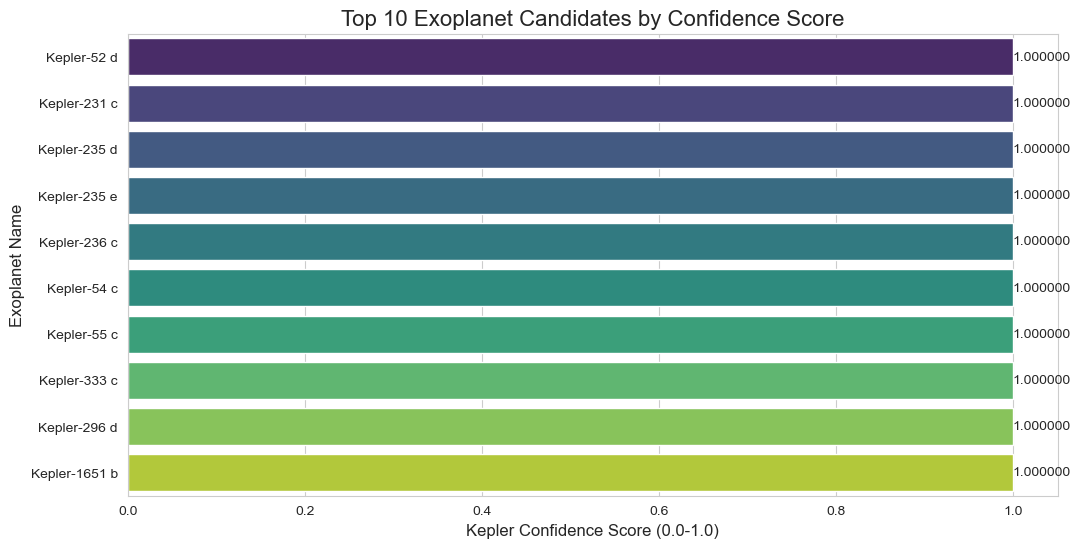

In [38]:
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")
ax=sns.barplot(x='Score',y='Planet_Name',data=en_iyi_10_aday,palette='viridis')
plt.title('Top 10 Exoplanet Candidates by Confidence Score',fontsize=16)
plt.xlabel('Kepler Confidence Score (0.0-1.0)',fontsize=12)
plt.ylabel('Exoplanet Name',fontsize=12)
for p in ax.patches:
    ax.annotate(format(p.get_width(),'3f'),
               (p.get_width(),
               p.get_y() + p.get_height()/2.),
               ha='center',va='center',
                xytext=(20,0), textcoords = 'offset points')
plt.show()